In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("winequality (1).csv")

print(df.head())
print(df.info())
print(df.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [4]:
df.fillna(df.mean(), inplace=True)

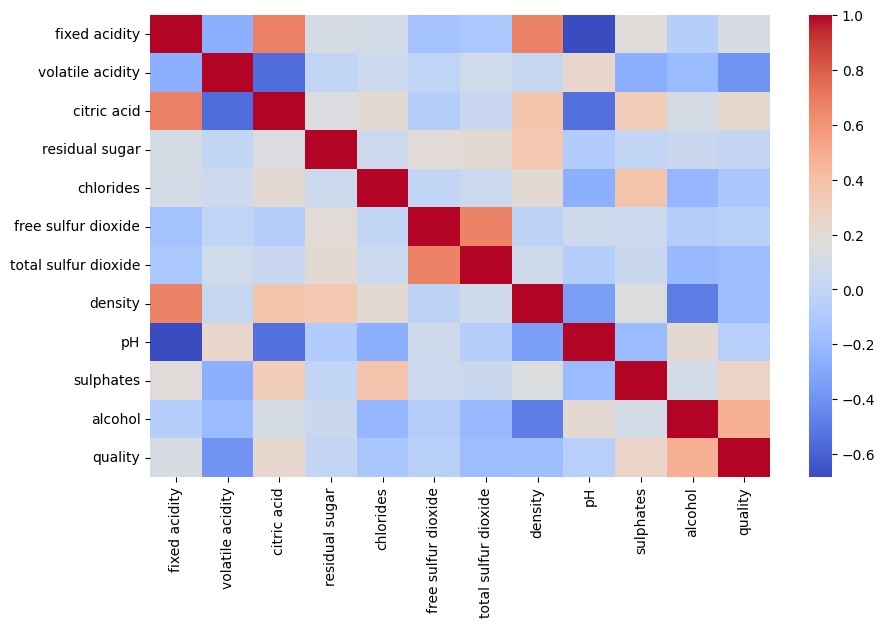

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [6]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print(df['quality_label'].value_counts())

quality_label
0    1382
1     217
Name: count, dtype: int64


In [7]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.859375
F1 Score: 0.3283582089552239
[[264   9]
 [ 36  11]]


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("F1 Score:", f1_score(y_test, y_pred_scaled))

Accuracy: 0.865625
F1 Score: 0.37681159420289856


In [12]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    
    print(name, acc)

Logistic 0.865625
KNN 0.88125
Decision Tree 0.88125


In [14]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: KNN


In [15]:
params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [16]:
y_pred_best = best_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.859375
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       273
           1       0.55      0.23      0.33        47

    accuracy                           0.86       320
   macro avg       0.72      0.60      0.62       320
weighted avg       0.83      0.86      0.83       320



In [17]:
importance = best_model.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_imp)

                 Feature  Importance
10               alcohol    0.560432
9              sulphates    0.170336
1       volatile acidity    0.114004
6   total sulfur dioxide    0.081635
5    free sulfur dioxide    0.073593
2            citric acid    0.000000
0          fixed acidity    0.000000
3         residual sugar    0.000000
4              chlorides    0.000000
8                     pH    0.000000
7                density    0.000000


In [18]:
import joblib

joblib.dump(best_model, "wine_model.pkl")

['wine_model.pkl']

In [19]:
import joblib

joblib.dump(best_model, "wine_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']